# 02 — Boxscore EDA

Understand the NBA CDN boxscore data: snapshot frequency, game clock format, score evolution patterns.

In [1]:
import sys
sys.path.insert(0, '/Users/chriswang/Desktop/prediction-market-exploration/nba-edge')

import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from nba_edge.data.s3_reader import discover_game_ids, load_boxscores_for_game
from nba_edge.models.analytical import parse_game_clock

In [2]:
# Discover games on a date with known data
games = discover_game_ids('2026-04-21')
print(f'Games on 2026-04-21: {len(games)}')
for g in games:
    print(f"  {g['game_id']} — {g['game_code']} ({g['away_team']}@{g['home_team']})")

Games on 2026-04-21: 9
  0042500101 — 20260419/ORLDET (ORL@DET)
  0042500151 — 20260419/PORSAS (POR@SAS)
  0042500132 — 20260420/TORCLE (TOR@CLE)
  0042500122 — 20260420/ATLNYK (ATL@NYK)
  0042500162 — 20260420/MINDEN (MIN@DEN)
  0042500112 — 20260421/PHIBOS (PHI@BOS)
  0042500152 — 20260421/PORSAS (POR@SAS)
  0042500172 — 20260421/HOULAL (HOU@LAL)
  0042500102 — 20260422/ORLDET (ORL@DET)


In [3]:
# Load boxscores for one game
game_id = games[0]['game_id']
snapshots = load_boxscores_for_game(game_id, '2026-04-21')
print(f'Snapshots for {game_id}: {len(snapshots)}')
print(f'First: {snapshots[0]}')
print(f'Last:  {snapshots[-1]}')

Snapshots for 0042500101: 1284
First: {'t_receipt': 1776643190.4421709, 'home_score': 51, 'away_score': 57, 'home_team': 'DET', 'away_team': 'ORL', 'period': 3, 'game_clock': 'PT11M26.00S', 'game_status': 2}
Last:  {'t_receipt': 1776647183.410552, 'home_score': 101, 'away_score': 112, 'home_team': 'DET', 'away_team': 'ORL', 'period': 4, 'game_clock': 'PT00M00.00S', 'game_status': 2}


Snapshot interval stats (seconds):
  mean:   3.1
  median: 3.1
  min:    3.1
  max:    3.6
  p95:    3.2


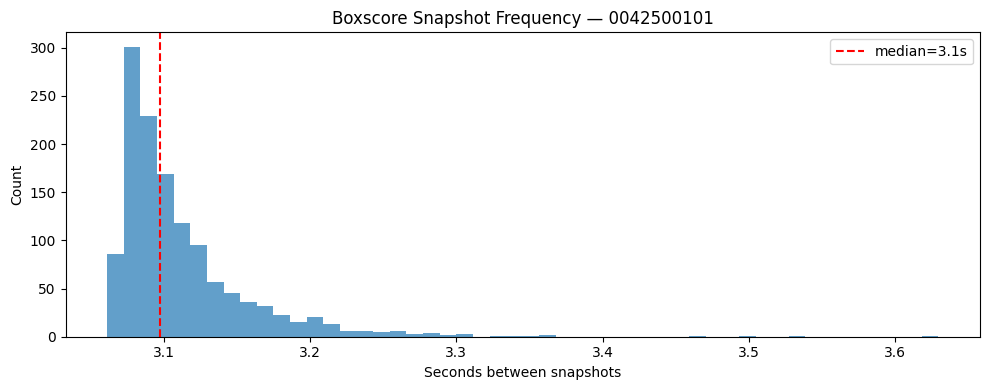

In [4]:
# Snapshot frequency — time between consecutive snapshots
times = [s['t_receipt'] for s in snapshots]
diffs = np.diff(times)

print(f'Snapshot interval stats (seconds):')
print(f'  mean:   {np.mean(diffs):.1f}')
print(f'  median: {np.median(diffs):.1f}')
print(f'  min:    {np.min(diffs):.1f}')
print(f'  max:    {np.max(diffs):.1f}')
print(f'  p95:    {np.percentile(diffs, 95):.1f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(diffs[diffs < 30], bins=50, edgecolor='none', alpha=0.7)
ax.set_xlabel('Seconds between snapshots')
ax.set_ylabel('Count')
ax.set_title(f'Boxscore Snapshot Frequency — {game_id}')
ax.axvline(np.median(diffs), color='red', linestyle='--', label=f'median={np.median(diffs):.1f}s')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Game clock parsing validation
print('Game clock samples:')
for s in snapshots[::len(snapshots)//10]:
    secs = parse_game_clock(s['period'], s['game_clock'])
    print(f"  P{s['period']} {s['game_clock']:>15s} → {secs:.0f}s remaining")

Game clock samples:
  P3     PT11M26.00S → 1406s remaining
  P3     PT09M23.00S → 1283s remaining
  P3     PT07M04.00S → 1144s remaining
  P3     PT03M43.00S → 943s remaining
  P3     PT01M52.00S → 832s remaining
  P3     PT00M00.00S → 720s remaining
  P4     PT08M15.00S → 495s remaining
  P4     PT06M48.00S → 408s remaining
  P4     PT03M45.00S → 225s remaining
  P4     PT02M19.00S → 139s remaining
  P4     PT00M10.40S → 10s remaining


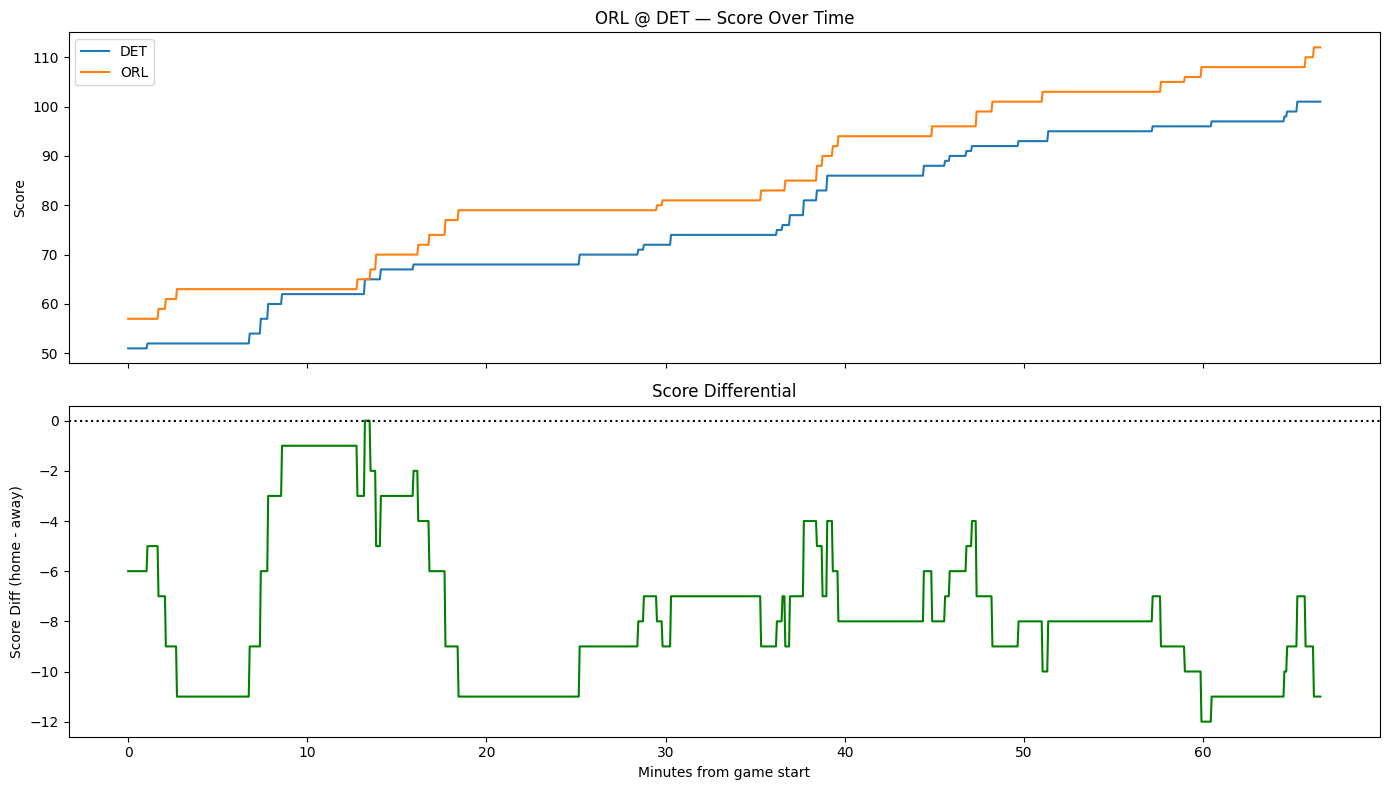

In [6]:
# Score evolution over time
df_game = pl.DataFrame(snapshots)
df_game = df_game.with_columns(
    ((pl.col('t_receipt') - pl.col('t_receipt').first()) / 60).alias('minutes'),
    (pl.col('home_score') - pl.col('away_score')).alias('score_diff'),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

home = snapshots[0]['home_team']
away = snapshots[0]['away_team']

# Scores
axes[0].plot(df_game['minutes'].to_numpy(), df_game['home_score'].to_numpy(), label=home)
axes[0].plot(df_game['minutes'].to_numpy(), df_game['away_score'].to_numpy(), label=away)
axes[0].set_ylabel('Score')
axes[0].set_title(f'{away} @ {home} — Score Over Time')
axes[0].legend()

# Score differential
axes[1].plot(df_game['minutes'].to_numpy(), df_game['score_diff'].to_numpy(), color='green')
axes[1].axhline(0, color='black', linestyle=':')
axes[1].set_xlabel('Minutes from game start')
axes[1].set_ylabel('Score Diff (home - away)')
axes[1].set_title('Score Differential')

plt.tight_layout()
plt.show()

In [7]:
# Compute scoring variance rate from this game
# Take pairs of snapshots, compute variance of score_diff changes
score_diffs = df_game['score_diff'].to_numpy()
time_secs = (df_game['t_receipt'] - df_game['t_receipt'].first()).to_numpy()

# Use 60-second windows to estimate variance rate
window = 60  # seconds
variances = []
for i in range(len(time_secs)):
    # Find snapshots ~60s later
    mask = (time_secs > time_secs[i] + window - 5) & (time_secs < time_secs[i] + window + 5)
    if mask.any():
        j = np.where(mask)[0][0]
        delta_score = score_diffs[j] - score_diffs[i]
        delta_time = time_secs[j] - time_secs[i]
        if delta_time > 0:
            variances.append(delta_score**2 / delta_time)

est_variance_rate = np.mean(variances) if variances else float('nan')
print(f'Estimated variance rate from this game: {est_variance_rate:.3f} pts²/s')
print(f'Expected NBA value: ~0.44 pts²/s')

Estimated variance rate from this game: 0.045 pts²/s
Expected NBA value: ~0.44 pts²/s


In [ ]:
# Check all available games to get a better variance estimate
all_variances = []
for date in ['2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-25']:
    try:
        day_games = discover_game_ids(date)
    except Exception:
        continue
    for g in day_games:
        snaps = load_boxscores_for_game(g['game_id'], date)
        if len(snaps) < 50:
            continue
        scores = [s['home_score'] - s['away_score'] for s in snaps]
        ts = [s['t_receipt'] for s in snaps]
        # Sample pairs ~60s apart
        for i in range(0, len(ts) - 1, 5):
            for j in range(i+1, min(i+20, len(ts))):
                dt = ts[j] - ts[i]
                if 50 < dt < 70:
                    ds = scores[j] - scores[i]
                    all_variances.append(ds**2 / dt)
                    break

if all_variances:
    print(f'Variance rate across {len(all_variances)} samples from multiple games:')
    print(f'  mean:   {np.mean(all_variances):.3f}')
    print(f'  median: {np.median(all_variances):.3f}')
    print(f'  std:    {np.std(all_variances):.3f}')
else:
    print('No variance samples collected')